# PLANTILLA EDA

**IMPORTANTE**: Recuerda hacer una copia de esta plantilla para no machacar la original.

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

#Automcompletar rapido
%config IPCompleter.greedy=True

## IMPORTAR LOS DATOS

In [2]:
ruta_proyecto = 'C:/Users/vifra/vidal cientifico de datos/Portafolio ML/Proyecto leadscoring/00_PROYECTO_LEADSCORING/'

In [3]:
nombre_cat = 'cat_resultado_calidad.pickle'
nombre_num = 'num_resultado_calidad.pickle'

In [4]:
cat = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_cat)
num = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_num)

## EDA CATEGORICAS

### Analisis estadistico

In [5]:
def frecuencias_cat(df_cat):
    resultado = df_cat.apply(lambda x: x.value_counts(normalize = True)).T.stack()\
                .to_frame().reset_index()\
                .rename(columns={'level_0':'Variable','level_1':'Valor',0: "Frecuencia"})\
                .sort_values(by = ['Variable','Frecuencia'])
    return(resultado)

In [6]:
#pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')

In [7]:
cat= cat.loc[(cat.no_llamar != 'yes') & (cat.no_enviar_email != 'yes') & (cat.ult_actividad != 'Email Bounced')]\
.drop(columns=['conociste_facebook',
              'conociste_referencias',
              'conociste_google',
              'no_enviar_email','no_llamar'])

In [8]:
frecuencias_cat(cat).head(74)

,Variable,Valor,Frecuencia
20,ambito,Healthcare Management,0.020887
23,ambito,International Business,0.023842
25,ambito,Media and Advertising,0.026404
30,ambito,Travel and Tourism,0.026404
17,ambito,"Banking, Investment And Insurance",0.040591
22,ambito,IT Projects Management,0.044926
29,ambito,Supply Chain Management,0.046897
18,ambito,Business Administration,0.051429
27,ambito,Operations Management,0.064631
26,ambito,OTROS,0.066601


In [9]:
print(cat.shape)
print(num.shape)

(5075, 6)
(5287, 6)


In [10]:
num = num[num.index.isin(cat.index)]

### Analisis grafico

In [11]:
def graficos_eda_categoricos(cat):
    
    #Se calcula el numero de filas que se necesita
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Se define el grafico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Se aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Se Crea el bucle que va añadiendo graficos
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

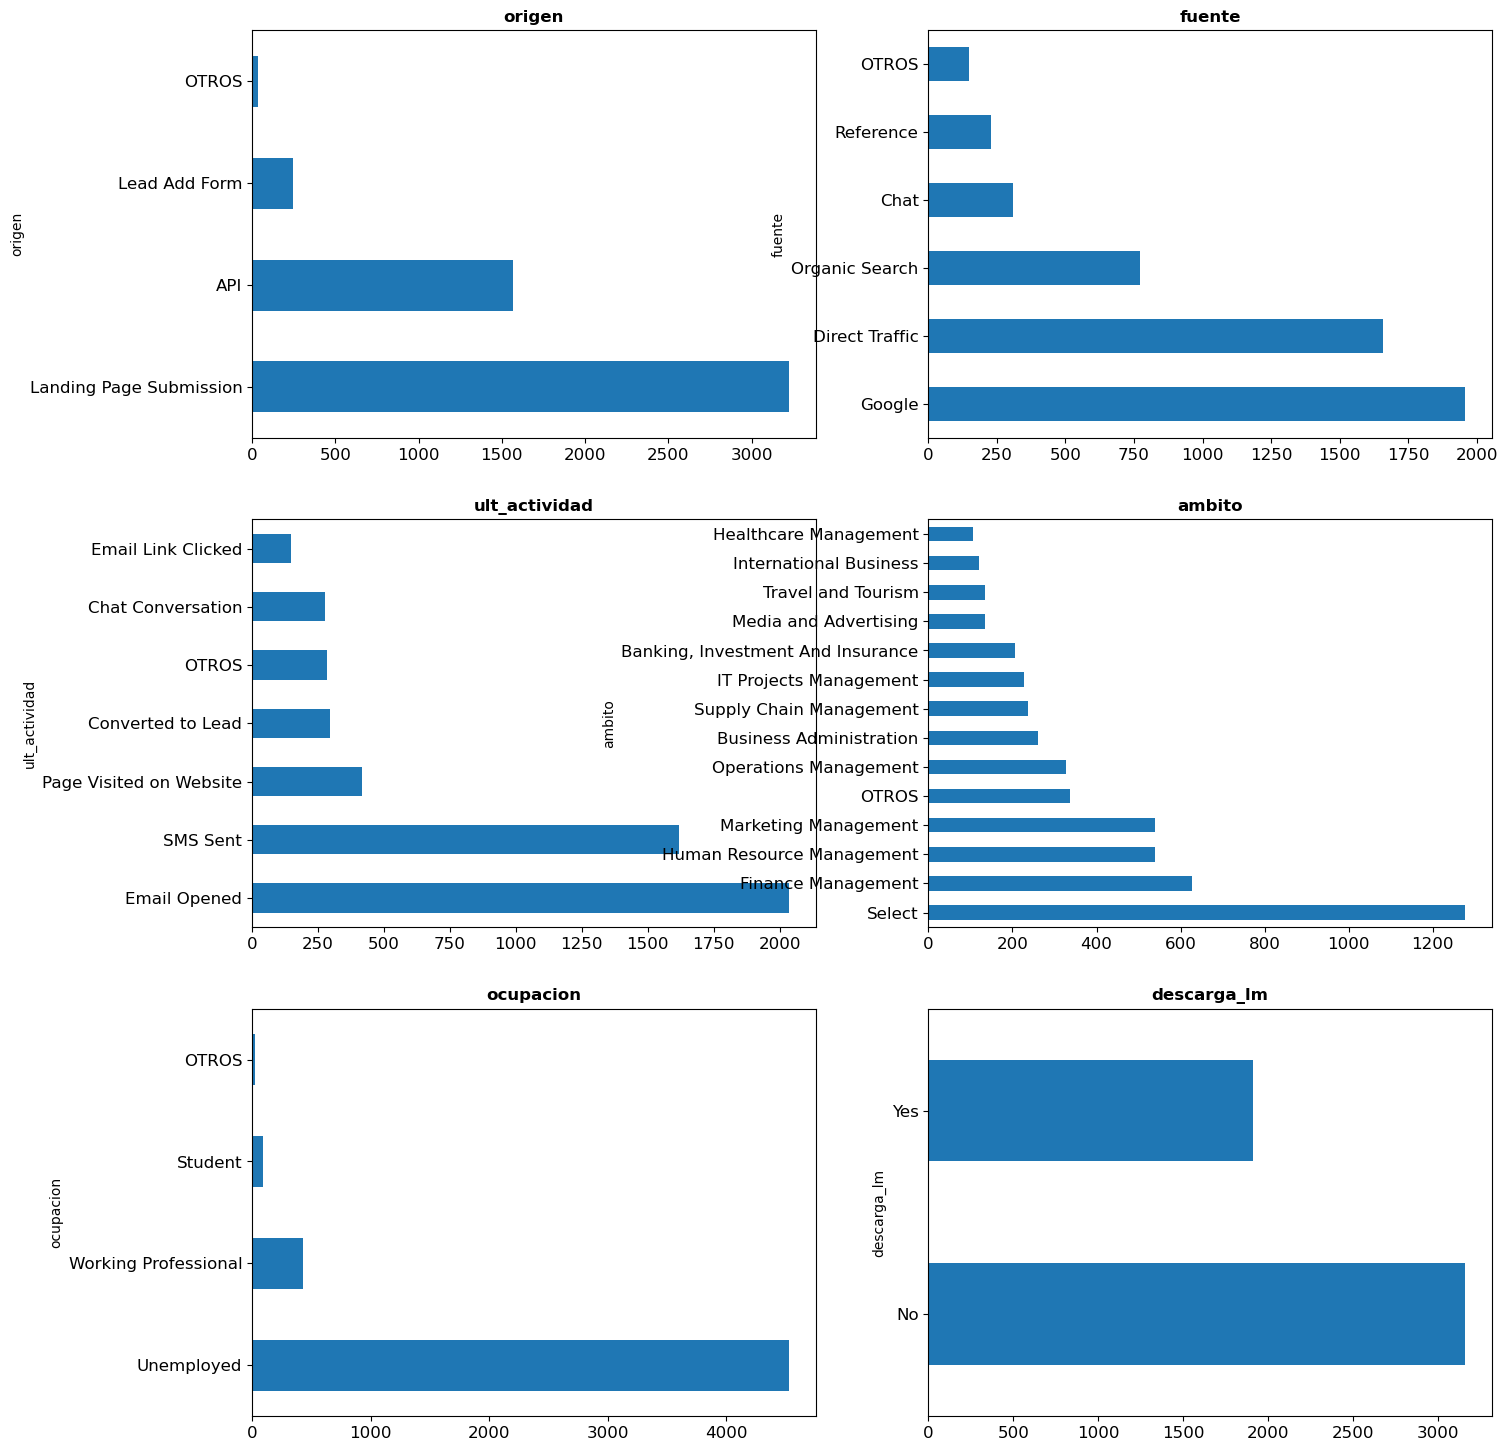

In [12]:
graficos_eda_categoricos(cat)

## EDA NUMERICAS

### Analisis estadistico

In [13]:
def estadisticos_cont(num):
    #Calculamos describe
    estadisticos = num.describe().T
    #Añadimos la mediana
    estadisticos['median'] = num.median()
    #Reordenamos para que la mediana esté al lado de la media
    estadisticos = estadisticos.iloc[:,[0,1,8,2,3,4,5,6,7]]
    #Lo devolvemos
    return(estadisticos)

In [14]:
estadisticos_cont(num)

,count,mean,median,std,min,25%,50%,75%,max
compra,5075.0,0.4067,0.0,0.491266,0.0,0.0,0.0,1.0,1.0
visitas_total,5075.0,4.133202,3.0,3.585433,0.0,2.0,3.0,5.0,50.0
tiempo_en_site_total,5075.0,597.303842,361.0,550.030569,0.0,130.0,361.0,1078.5,2272.0
paginas_vistas_visita,5075.0,2.883515,2.5,1.936638,0.0,2.0,2.5,4.0,16.0
score_actividad,5075.0,14.040985,14.0,0.973584,7.0,14.0,14.0,14.0,18.0
score_perfil,5075.0,16.73734,17.0,1.422057,11.0,16.0,17.0,17.0,20.0


### Analisis grafico

In [15]:
def graficos_eda_continuas(num):
    
    #SeC calculas el numero de fila que se necesita
    from math import ceil
    filas = ceil(num.shape[1] / 2)

    #Se define el grafico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Se aplana para iterar por el grafico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Se crea el bucle que va añadiendo graficos
    for cada, variable in enumerate(num):
        num[variable].plot.density(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

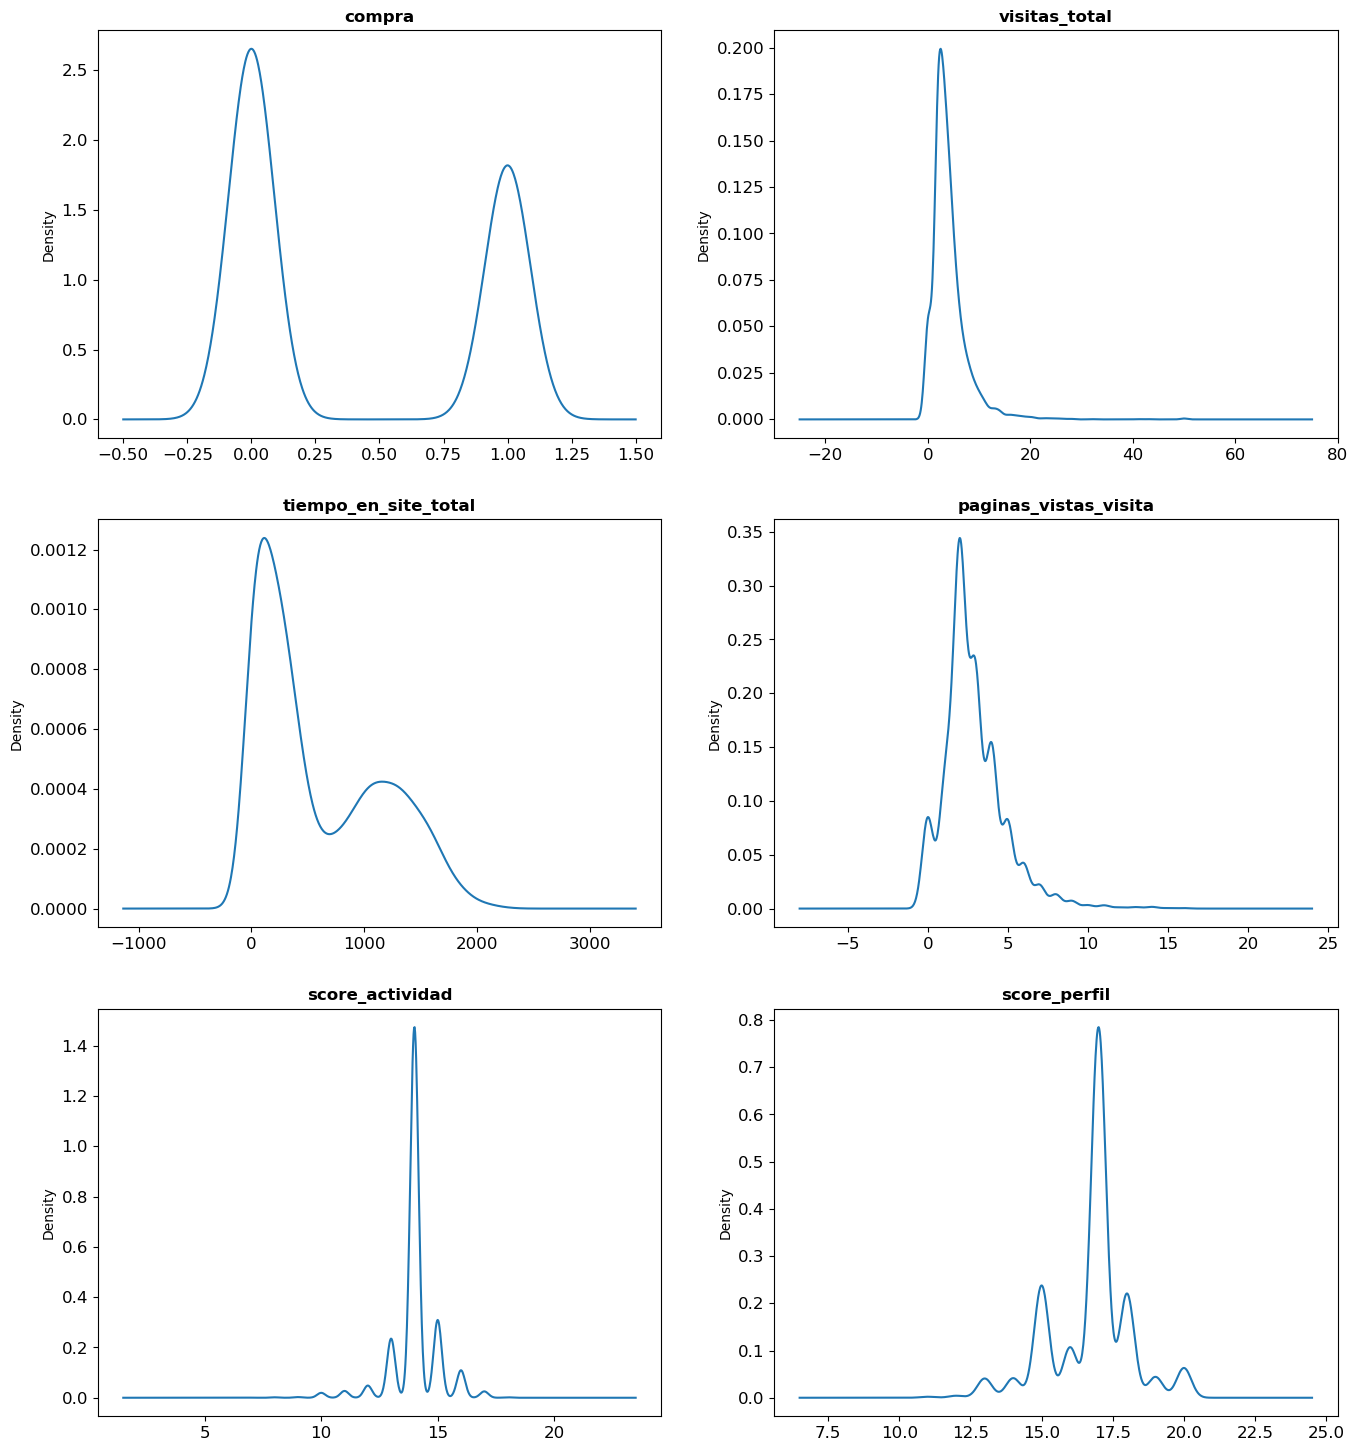

In [16]:
graficos_eda_continuas(num)

## GUARDAR DATASETS TRAS CALIDAD DE DATOS

In [19]:
num

,compra,visitas_total,tiempo_en_site_total,paginas_vistas_visita,score_actividad,score_perfil
id,,,,,,
660737,0,0,0,0.00,15.0,15.0
660728,0,5,674,2.50,15.0,15.0
660727,1,2,1532,2.00,14.0,20.0
660719,0,1,305,1.00,13.0,17.0
660681,1,2,1428,1.00,15.0,18.0
...,...,...,...,...,...,...
579564,1,8,1845,2.67,15.0,17.0
579546,0,2,238,2.00,14.0,19.0
579545,0,2,199,2.00,13.0,20.0


Guarda los avances en cat y num con un sufijo para poder guardar o recuperar avances del proyecto.

En formato pickle para no perder las modificaciones de metadatos.


In [17]:
#Definir los nombres de los archivos
ruta_cat = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'cat_resultado_eda.pickle'
ruta_num = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'num_resultado_eda.pickle'

In [18]:
#Guardar los archivos
cat.to_pickle(ruta_cat)
num.to_pickle(ruta_num)